# Assignment 2 (90 marks)

## *The adverse health effects of air pollution - are we making any progress?*

<p><img src=WDI_csv/air.jpg width="900"></p>
<p><strong>Credit:</strong>  <a href="https://www.flickr.com/people/44221799@N08/">Flickr/E4C</a> </p>

In [7]:
# Load relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as sm
import warnings

warnings.filterwarnings("ignore")  # Suppress all warnings

<h2>Introduction</h2>
<p><strong>Business Context.</strong> Air pollution is a very serious issue that the global population is currently dealing with. The abundance of air pollutants is not only contributing to global warming, but it is also causing problematic health issues to the population. There have been numerous efforts to protect and improve air quality across most nations. However, it seems that we are making very little progress. One of the main causes of this is the fact that the majority of air pollutants are derived from the burning of fossil fuels such as <em>coal</em>. Big industries and several other economical and political factors have slowed the progress towards the use of renewable energy by promoting the use of fossil fuels. Nevertheless, if we educate the general population and create awareness of this issue, we will be able to overcome this problem in the future.      </p>
<p>For this case, you have been hired as a data science consultant for an important environmental organization. In order to promote awareness of environmental and greenhouse gas issues, your client is interested in a study of <strong>plausible impacts of air contamination on the health of the global population</strong>. They have gathered some <em>raw</em> data provided by the <a href="https://www.who.int/">World Health Organization</a>, <a href="http://www.healthdata.org/">The Institute for Health Metrics and Evaluation</a> and the <a href="https://www.worldbank.org/">World Bank Group</a>. Your task is to conduct data analysis, search for potential information, and create visualizations that the client can use for their campaigns and grant applications. </p>
<p><strong>Analytical Context.</strong> You are given a folder, named <code>files</code> with <em>raw</em> data. This data contains quite a large number of variables and it is in a fairly disorganized state. In addition, one of the datasets contains very poor documentation, segmented into several datasets. Your objective will be to:</p>
<ol>
<li>Extract and clean the relevant data. You will have to manipulate several datasets to obtain useful information for the case. </li>
<li>Conduct Exploratory Data Analysis. You will have to create meaningful plots, formulate meaningful hypotheses and study the relationship between various indicators related to air pollution.</li>
</ol>
<p>Additionally, the client has some broad questions they would like to answer:<br />
1. Are we making any progress in reducing the amount of emitted pollutants across the globe?<br />
2. Which are the critical regions where we should start environmental campaigns?<br />
3. Are we making any progress in the prevention of deaths related to air pollution?<br />
4. Which demographic characteristics seem to correlate with the number of health-related issues derived from air pollution? </p>

<h2>Extracting and cleaning relevant data</h2>
<p>Let's take a look at the data provided by the client in the <code>files</code> folder. There, we see another folder  named <code>WDI_csv</code> with several CSV files corresponding to the World Bank's primary <a href="https://datacatalog.worldbank.org/dataset/world-development-indicators">World Development Indicators</a>. The client stated that this data may contain some useful information relevant to our study, but they have not told us anything aside from that. Thus, we are on our own in finding and extracting the relevant data for our study. This we will do next. </p>
<p>Let's take a peek at the file <code>WDIData.csv</code>:</p>

In [10]:
WDI_data = pd.read_csv("WDI_csv/WDIData.csv")
print(WDI_data.columns)
print(WDI_data.info())
WDI_data.head()

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', 'Unnamed: 64'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377256 entries, 0 to 377255
Data columns (total 65 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    377256 non-null  object 
 1   Country Code    377256 non-null  object 
 2   Indicator Name  377256 non-null  object 
 3   Indicator Co

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,Unnamed: 64
0,Arab World,ARB,"2005 PPP conversion factor, GDP (LCU per inter...",PA.NUS.PPP.05,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"2005 PPP conversion factor, private consumptio...",PA.NUS.PRVT.PP.05,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,82.783289,83.120303,83.533457,83.897596,84.171599,84.510171,NaN,NaN,NaN,NaN
3,Arab World,ARB,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,86.428272,87.070576,88.176836,87.342739,89.130121,89.678685,90.273687,NaN,NaN,NaN
4,Arab World,ARB,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,73.942103,75.244104,77.162305,75.538976,78.741152,79.665635,80.749293,NaN,NaN,NaN


<p>The data seems to have a large number of indicators dating from 1960. There are also columns containing country names and codes. Notice that the first couple of rows say <code>Arab World</code>, which may indicate that the data contains broad regional data as well. We notice also that there are at least 100,000 entries with <code>NaN</code> values for each year column.</p>
<p>Since we are interested in environmental indicators, we must get rid of any rows not relevant to our study. However, the number of indicators seems to be quite large and a manual inspection seems impossible. Let's load the file <code>WDISeries.csv</code> which seems to contain more information about the indicators:</p>

In [12]:
WDI_ids = pd.read_csv("WDI_csv/WDISeries.csv")
print(WDI_ids.columns)
WDI_ids.head()

Index(['Series Code', 'Topic', 'Indicator Name', 'Short definition',
       'Long definition', 'Unit of measure', 'Periodicity', 'Base Period',
       'Other notes', 'Aggregation method', 'Limitations and exceptions',
       'Notes from original source', 'General comments', 'Source',
       'Statistical concept and methodology', 'Development relevance',
       'Related source links', 'Other web links', 'Related indicators',
       'License Type', 'Unnamed: 20'],
      dtype='object')


,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,AG.AGR.TRAC.NO,Environment: Agricultural production,"Agricultural machinery, tractors",NaN,Agricultural machinery refers to the number of...,NaN,Annual,NaN,NaN,Sum,...,NaN,NaN,"Food and Agriculture Organization, electronic ...",A tractor provides the power and traction to m...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0,NaN
1,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0,NaN
2,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0,NaN
3,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,NaN,Sum,...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agricultural land constitutes only a part of a...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0,NaN
4,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agriculture is still a major sector in many ec...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0,NaN


<p>Bingo! The <code>WDI_ids</code> DataFrame contains a column named <code>Topic</code>. Moreover, it seems that <em>Environment</em> is listed as a key topic in the column.</p>

<h3>Exercise 1 (4 marks):</h3>
<p>Extract all the rows that have the topic key <em>Environment</em> in <code>WDI_ids</code>. Add to the resulting DataFrame a new column named <code>Subtopic</code> which contains the corresponding subtopic of the indicator. For example, the subtopic of <code>Environment: Agricultural production</code> is <code>Agricultural production</code>. Which subtopics do you think are of interest to us?</p>
<p><strong>Hint:</strong> Remember that you can apply string methods to Series using the <code>str()</code> method of <code>pandas</code>. </p>

**Answer.**

In [16]:
#Subsetting to rows that only have Environment in Topic
WDI_environment = WDI_ids[WDI_ids['Topic'].apply(lambda x: 'Environment' in x)]
WDI_environment['Topic'].unique()

array(['Environment: Agricultural production', 'Environment: Land use',
       'Environment: Energy production & use', 'Environment: Emissions',
       'Environment: Biodiversity & protected areas',
       'Environment: Density & urbanization', 'Environment: Freshwater',
       'Environment: Natural resources contribution to GDP'], dtype=object)

In [17]:
#Creating subtopics
topic_short = {
    "Environment: Agricultural production": "Agricultural production",
    'Environment: Land use': 'Land use',
    'Environment: Energy production & use': 'Energy production & use',
    'Environment: Emissions': 'Emissions',
    'Environment: Biodiversity & protected areas': 'Biodiversity & protected areas',
    'Environment: Density & urbanization': 'Density & urbanization',
    'Environment: Freshwater': 'Freshwater',
    'Environment: Natural resources contribution to GDP': 'Natural resources contribution to GDP'
}

WDI_environment['Subtopic'] = WDI_environment['Topic'].apply(lambda x: topic_short[x])
WDI_environment.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20,Subtopic
0,AG.AGR.TRAC.NO,Environment: Agricultural production,"Agricultural machinery, tractors",NaN,Agricultural machinery refers to the number of...,NaN,Annual,NaN,NaN,Sum,...,NaN,"Food and Agriculture Organization, electronic ...",A tractor provides the power and traction to m...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0,NaN,Agricultural production
1,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0,NaN,Agricultural production
2,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0,NaN,Agricultural production
3,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,NaN,Sum,...,NaN,"Food and Agriculture Organization, electronic ...",Agricultural land constitutes only a part of a...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0,NaN,Land use
4,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,"Food and Agriculture Organization, electronic ...",Agriculture is still a major sector in many ec...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0,NaN,Land use


**Which subtopics are relevant?**

To answer our research questions it would be useful to look into the following subtopics: emissions, energy production and use, land use, as well as density and urbanization. 
Emissions will be the most useful of all subtopics as they will provide information about how much pollution we create. 
The other subtopics will be useful in providing information about critical areas of pollution, human health and other factors. 

-------

<h3>Exercise 2 (4 marks):</h3>
<p>Use the results of Exercise 1 to create a new DataFrame with the history of all emissions indicators for countries and major regions. Call this new DataFrame <code>Emissions_df</code>. How many emissions indicators are in the study?</p>

**Answer.**

In [22]:
#Notice that all of the indicators have a unique code.
#From Exercise 1, find all the series codes for emissions and filter onto the other df
Emissions = WDI_environment[WDI_environment['Subtopic'] == 'Emissions']

#Create df - Emissions_df
Emissions_df = WDI_data.copy()
Emissions_df = Emissions_df[Emissions_df['Indicator Code'].isin(Emissions['Series Code'])]
Emissions_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,Unnamed: 64
64,Arab World,ARB,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,Arab World,ARB,Agricultural methane emissions (thousand metri...,EN.ATM.METH.AG.KT.CE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,Arab World,ARB,Agricultural nitrous oxide emissions (% of total),EN.ATM.NOXE.AG.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,Arab World,ARB,Agricultural nitrous oxide emissions (thousand...,EN.ATM.NOXE.AG.KT.CE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,Arab World,ARB,CO2 emissions (kg per 2010 US$ of GDP),EN.ATM.CO2E.KD.GD,NaN,NaN,NaN,NaN,NaN,NaN,...,0.757162,0.770413,0.737665,0.769023,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
unique_indicator = len(Emissions_df['Indicator Name'].unique())

print(f'There are {unique_indicator} emissions indicators in the study.')

There are 42 emissions indicators in the study.


-------

<h3>Exercise 3 (4 marks):</h3>
<p>The DataFrame <code>Emissions_df</code> has one column per year of observation. Data in this form is usually referred to as data in <em>wide format</em>, as the number of columns is high. However, it might be easier to query and filter the data if we had a single column containing the year in which each indicator was calculated. This way, <em>each observation will be represented by a single row</em>. Use the <code>pandas</code> function <a href="https://pandas.pydata.org/docs/reference/api/pandas.melt.html"><code>melt()</code></a> to reshape the <code>Emissions_df</code> data into <em>long format</em>. The resulting DataFrame should contain a pair of new columns named <code>Year</code> and <code>Indicator Value</code>:</p>

**Answer.**

In [27]:
#Get an understanding of which columns to keep/melt
print(Emissions_df.shape)
Emissions_df.columns

#keep first 4, melt the rest > years

(11088, 65)


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', 'Unnamed: 64'],
      dtype='object')

In [28]:
Emissions_df = pd.melt(
    Emissions_df, 
    id_vars=['Country Name','Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Indicator Value'
)

In [29]:
print(Emissions_df.shape)
Emissions_df.head()

(676368, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
0,Arab World,ARB,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1960,NaN
1,Arab World,ARB,Agricultural methane emissions (thousand metri...,EN.ATM.METH.AG.KT.CE,1960,NaN
2,Arab World,ARB,Agricultural nitrous oxide emissions (% of total),EN.ATM.NOXE.AG.ZS,1960,NaN
3,Arab World,ARB,Agricultural nitrous oxide emissions (thousand...,EN.ATM.NOXE.AG.KT.CE,1960,NaN
4,Arab World,ARB,CO2 emissions (kg per 2010 US$ of GDP),EN.ATM.CO2E.KD.GD,1960,NaN


-------

<h3>Exercise 4 (4 marks):</h3>
<p>The column <code>Indicator Value</code> of the new <code>Emissions_df</code> contains a bunch of <code>NaN</code> values. Additionally, the <code>Year</code> column contains an <code>Unnamed: 64</code> value. What procedure should we follow to clean these missing values in our DataFrame? Proceed with your suggested cleaning process.</p>

**Answer.**

**Cleaning Process Plan**

First, I will be checking the Unnamed: 64 values. 'Unnamed' is typically written in the data when an empty column has been included. Therefore, if this is true and there is no data in these rows, we should remove them. 
Now we will check to make sure this is true.

In [34]:
#To support this claim, we notice that the length of the column is the same as the other columns before the melt.
unnamed_row = Emissions_df[Emissions_df['Year'].str.contains('Unnamed: 64')]
unnamed_row.shape

#We should check the data in the rows

(11088, 6)

In [35]:
#Checking the Indicator Value of all rows with Unnamed 64
#Find the index of the Year column, then check the Indicator Value column (1 to the right)
year_col_index = np.where(Emissions_df.columns == 'Year')[0][0]

Indicator_values_unnamed = unnamed_row.iloc[:, year_col_index + 1] 
unique_values = Indicator_values_unnamed.unique()
print(unique_values)

#all Indicator Values are nan > so there is no information in these rows, which concludes our
#check that this was an empty column that was included in the data.
#Plan to drop all of these rows!

[nan]


In [36]:
#Dropping all of the Unnamed 64 rows
Emissions_df = Emissions_df[Emissions_df['Year'] != 'Unnamed: 64']
print(Emissions_df.shape)

(665280, 6)


**Cleaning Process Plan, Continued**

Now that we have removed the Unnamed: 64 rows, we must clean up the NaN values. To decide what to do, we must find out how much of the data, NaN represents in the Indicator Value column.

In [38]:
print(Emissions_df.shape)
print('-' *15)
print(Emissions_df.isnull().sum())
print('-' *15)

percent_nan = Emissions_df['Indicator Value'].isnull().mean()
percent_nan = (percent_nan*100).round(2)
print(f'{percent_nan}% of the Indicator Value column is made of NaNs')

(665280, 6)
---------------
Country Name            0
Country Code            0
Indicator Name          0
Indicator Code          0
Year                    0
Indicator Value    339422
dtype: int64
---------------
51.02% of the Indicator Value column is made of NaNs


**Cleaning Process, continued**

We can observe NaN values for over half of the Indicator Value column. However, each data entry in this column is unique to each year, Indicator and country, so there is no way of accurately imputing the data. Therefore, even though NaNs represent a large amount of the column, we must drop the rows so we do not inaccurately derive any conclusions.

In [40]:
Emissions_df = Emissions_df.dropna(subset=['Indicator Value'])

In [41]:
Emissions_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
7,Arab World,ARB,CO2 emissions (kt),EN.ATM.CO2E.KT,1960,59535.396567
8,Arab World,ARB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1960,0.645736
10,Arab World,ARB,CO2 emissions from gaseous fuel consumption (%...,EN.ATM.CO2E.GF.ZS,1960,5.041292
12,Arab World,ARB,CO2 emissions from liquid fuel consumption (% ...,EN.ATM.CO2E.LF.ZS,1960,84.851473
13,Arab World,ARB,CO2 emissions from liquid fuel consumption (kt),EN.ATM.CO2E.LF.KT,1960,50539.802737


**FINAL CLEANING Overview**

Overall, the dataset has been cleaned by dropping all rows that included NaN values and 'Unnamed: 64'. 

-------

<h3>Exercise 5 (4 marks):</h3>
<p>Split the <code>Emissions_df</code> into two DataFrames, one containing only countries and the other containing only regions. Name these <code>Emissions_C_df</code> and <code>Emissions_R_df</code> respectively.</p>
<p><strong>Hint:</strong> You may want to inspect the file <code>WDICountry.csv</code> for this task. Region country codes may be found by looking at <code>null</code> values of the <code>Region</code> column in <code>WDICountry</code>.</p>

**Answer.**

In [46]:
WDI_country = pd.read_csv("WDI_csv/WDICountry.csv")

#Filtering for countries when Region value is not NaN
countries = WDI_country[WDI_country['Region'].notna()]

Emissions_C_df = Emissions_df[Emissions_df['Country Code'].isin(countries['Country Code'])]
Emissions_C_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
1981,Afghanistan,AFG,CO2 emissions (kt),EN.ATM.CO2E.KT,1960,414.371000
1982,Afghanistan,AFG,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1960,0.046057
1984,Afghanistan,AFG,CO2 emissions from gaseous fuel consumption (%...,EN.ATM.CO2E.GF.ZS,1960,0.000000
1985,Afghanistan,AFG,CO2 emissions from gaseous fuel consumption (kt),EN.ATM.CO2E.GF.KT,1960,0.000000
1986,Afghanistan,AFG,CO2 emissions from liquid fuel consumption (% ...,EN.ATM.CO2E.LF.ZS,1960,65.486726


In [47]:
#Filtering for regions when Region is NaN
regions = WDI_country[WDI_country['Region'].isna()]
Emissions_R_df = Emissions_df[Emissions_df['Country Code'].isin(regions['Country Code'])]
Emissions_R_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
7,Arab World,ARB,CO2 emissions (kt),EN.ATM.CO2E.KT,1960,59535.396567
8,Arab World,ARB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1960,0.645736
10,Arab World,ARB,CO2 emissions from gaseous fuel consumption (%...,EN.ATM.CO2E.GF.ZS,1960,5.041292
12,Arab World,ARB,CO2 emissions from liquid fuel consumption (% ...,EN.ATM.CO2E.LF.ZS,1960,84.851473
13,Arab World,ARB,CO2 emissions from liquid fuel consumption (kt),EN.ATM.CO2E.LF.KT,1960,50539.802737


-------

<h2>Finalizing the cleaning for our study</h2>
<p>Our data has improved a lot by now. However, since the number of indicators is still quite large, let us focus our study on the following indicators for now:</p>
<ul>
<li>
<p><strong>Total greenhouse gas emissions (kt of CO2 equivalent), EN.ATM.GHGT.KT.CE</strong>: The total of greenhouse emissions includes CO2, Methane, Nitrous oxide, among other pollutant gases. Measured in kilotons.</p>
</li>
<li>
<p><strong>CO2 emissions (kt), EN.ATM.CO2E.KT</strong>: Carbon dioxide emissions are those stemming from the burning of fossil fuels and the manufacture of cement. They include carbon dioxide produced during consumption of solid, liquid, and gas fuels and gas flaring.  </p>
</li>
<li>
<p><strong>Methane emissions (kt of CO2 equivalent), EN.ATM.METH.KT.CE</strong>: Methane emissions are those stemming from human activities such as agriculture and from industrial methane production.</p>
</li>
<li>
<p><strong>Nitrous oxide emissions (kt of CO2 equivalent), EN.ATM.NOXE.KT.CE</strong>: Nitrous oxide emissions are emissions from agricultural biomass burning, industrial activities, and livestock management.</p>
</li>
<li>
<p><strong>Other greenhouse gas emissions, HFC, PFC and SF6 (kt of CO2 equivalent), EN.ATM.GHGO.KT.CE</strong>: Other pollutant gases.</p>
</li>
<li>
<p><strong>PM2.5 air pollution, mean annual exposure (micrograms per cubic meter), EN.ATM.PM25.MC.M3</strong>: Population-weighted exposure to ambient PM2.5 pollution is defined as the average level of exposure of a nation's population to concentrations of suspended particles measuring less than 2.5 microns in aerodynamic diameter, which are capable of penetrating deep into the respiratory tract and causing severe health damage. Exposure is calculated by weighting mean annual concentrations of PM2.5 by population in both urban and rural areas.</p>
</li>
<li>
<p><strong>PM2.5 air pollution, population exposed to levels exceeding WHO guideline value (% of total), EN.ATM.PM25.MC.ZS</strong>: Percent of population exposed to ambient concentrations of PM2.5 that exceed the World Health Organization (WHO) guideline value.</p>
</li>
</ul>

<h3>Exercise 6 (5 marks) :</h3>
<p>For each of the emissions DataFrames, extract the rows corresponding to the above indicators of interest. Replace the long names of the indicators by the short names <code>Total</code>, <code>CO2</code>, <code>CH4</code>, <code>N2O</code>, <code>Other</code>, <code>PM2.5</code>, and <code>PM2.5_WHO</code>. (This will be helpful later when we need to label plots of our data.) </p>

**Answer.**

In [52]:
interests = ['EN.ATM.GHGT.KT.CE', 'EN.ATM.CO2E.KT', 'EN.ATM.METH.KT.CE', 
             'EN.ATM.NOXE.KT.CE', 'EN.ATM.GHGO.KT.CE', 'EN.ATM.PM25.MC.M3','EN.ATM.PM25.MC.ZS']

Emissions_C_df = Emissions_C_df[Emissions_C_df['Indicator Code'].isin(interests)]
Emissions_R_df = Emissions_R_df[Emissions_R_df['Indicator Code'].isin(interests)]

In [53]:
indicator_short = {'EN.ATM.GHGT.KT.CE': 'Total', 
                   'EN.ATM.CO2E.KT': 'CO2', 
                   'EN.ATM.METH.KT.CE': 'CH4', 
                   'EN.ATM.NOXE.KT.CE': 'NO2', 
                   'EN.ATM.GHGO.KT.CE': 'Other', 
                   'EN.ATM.PM25.MC.M3': 'PM2.5',
                   'EN.ATM.PM25.MC.ZS': 'PM2.5_WHO'
                  }

Emissions_C_df.loc[Emissions_C_df['Indicator Code'].isin(indicator_short.keys()), 'Indicator Name'] = Emissions_C_df['Indicator Code'].map(indicator_short)
Emissions_R_df.loc[Emissions_R_df['Indicator Code'].isin(indicator_short.keys()), 'Indicator Name'] = Emissions_R_df['Indicator Code'].map(indicator_short)

In [54]:
Emissions_C_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
1981,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1960,414.371
2023,Albania,ALB,CO2,EN.ATM.CO2E.KT,1960,2024.184
2065,Algeria,DZA,CO2,EN.ATM.CO2E.KT,1960,6160.560
2191,Angola,AGO,CO2,EN.ATM.CO2E.KT,1960,550.050
2233,Antigua and Barbuda,ATG,CO2,EN.ATM.CO2E.KT,1960,36.670


In [55]:
Emissions_R_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
7,Arab World,ARB,CO2,EN.ATM.CO2E.KT,1960,5.953540e+04
49,Caribbean small states,CSS,CO2,EN.ATM.CO2E.KT,1960,5.878201e+03
91,Central Europe and the Baltics,CEB,CO2,EN.ATM.CO2E.KT,1960,4.665334e+05
133,Early-demographic dividend,EAR,CO2,EN.ATM.CO2E.KT,1960,5.821834e+05
175,East Asia & Pacific,EAS,CO2,EN.ATM.CO2E.KT,1960,1.210072e+06


-------

<h2>Where shall the client start environmental campaigns?</h2>
<p>Now the DataFrames <code>Emissions_C_df</code> and <code>Emissions_R_df</code> seem to be in a good shape. Let's proceed to conduct some exploratory data analysis so that we can make recommendations to our client.</p>

<h3>Exercise 7 (15 marks):</h3>
<p>Let's first calculate some basic information about the main indicators across the globe.</p>
<h4>7.1 (5 marks)</h4>
<p>Compute some basic statistics of the amount of kt of emissions for each of the four main pollutants (<code>CO2, CH4, N2O, Others</code>) over the years. Use the <code>Emissions_C_df</code> data frame. What trends do you see? </p>

**Answer.**

In [60]:
#Creating a dataframe with the basic statistics for each pollutant and year
#Then I will observe each pollutant individually
pollutants = ['CO2','NO2','CH4', 'Other']
Emissions_C_df_pollutants = Emissions_C_df[Emissions_C_df['Indicator Name'].isin(pollutants)]

emissions_stats = Emissions_C_df_pollutants.groupby(['Year', 'Indicator Name']).agg(
    {'Indicator Value': ['mean', 'std', 'sum', 'min', lambda x: x.quantile(0.25), 
                         'median', lambda x: x.quantile(0.75), 'max']}).reset_index()
emissions_stats.columns =['Year', 'Indicator Name', 'mean', 'std', 'sum', 'min', 'Q1', 'median', 'Q3', 'max']

**CO2** ********************

In [62]:
emissions_stats[emissions_stats.iloc[:,1] == 'CO2'].head()

,Year,Indicator Name,mean,std,sum,min,Q1,median,Q3,max
0,1960,CO2,43864.241159,249106.821991,6623500.415,11.001,159.51450,997.424,11349.36500,2890696.100
1,1961,CO2,43016.467250,244197.472658,6538503.022,3.667,155.84750,1067.097,11635.39100,2880505.507
2,1962,CO2,43651.539390,249912.669011,6722337.066,3.667,132.92875,1140.437,11465.79225,2987207.873
3,1963,CO2,45599.499871,260004.403691,7067922.480,3.667,122.84450,1213.777,12244.11300,3119230.874
4,1964,CO2,46178.029919,266111.202103,7434662.817,7.334,143.01300,1243.113,12838.16700,3255995.306


In [63]:
emissions_stats[emissions_stats.iloc[:,1] == 'CO2'].tail()

,Year,Indicator Name,mean,std,sum,min,Q1,median,Q3,max
171,2010,CO2,155782.613970,746461.237878,3.162387e+07,7.334,1442.96450,7777.7070,61783.44950,8.776040e+06
175,2011,CO2,161941.999808,801308.170163,3.287423e+07,7.334,1488.80200,8368.0940,57296.87500,9.733538e+06
179,2012,CO2,162632.874078,810994.403809,3.350237e+07,11.001,1335.70475,8830.1360,58137.53475,1.002857e+07
182,2013,CO2,163074.533966,825234.857045,3.359335e+07,11.001,1280.69975,8743.9615,58852.59975,1.025801e+07
183,2014,CO2,165114.116327,833535.700351,3.384839e+07,11.001,1334.78800,9108.8280,59863.77500,1.029193e+07


**CH4** ********************

In [65]:
emissions_stats[emissions_stats.iloc[:,1] == 'CH4'].head()

,Year,Indicator Name,mean,std,sum,min,Q1,median,Q3,max
10,1970,CH4,26057.280609,80823.032375,5.289628e+06,0.596744,601.7685,4574.45,16669.70,781088.0
14,1971,CH4,25265.323492,81420.782843,5.128861e+06,0.622194,605.2385,4578.67,14634.45,813814.0
18,1972,CH4,26324.434722,83570.576761,5.343860e+06,0.648717,635.5225,4405.45,16116.00,825771.0
22,1973,CH4,26622.476042,83516.078127,5.404363e+06,0.675492,657.3465,4329.59,17349.60,826991.0
26,1974,CH4,26411.137428,83995.213710,5.361461e+06,0.701368,667.4590,4286.67,15263.15,830833.0


In [66]:
emissions_stats[emissions_stats.iloc[:,1] == 'CH4'].tail()

,Year,Indicator Name,mean,std,sum,min,Q1,median,Q3,max
162,2008,CH4,37410.279986,130812.927303,7.631697e+06,1.32378,1237.7650,6728.4150,22773.8750,1.537220e+06
166,2009,CH4,38210.173914,134289.968493,7.756665e+06,1.32889,1288.3350,7214.2000,23251.8500,1.582750e+06
170,2010,CH4,37883.007264,136795.018840,7.803899e+06,0.00000,1268.7475,6724.8400,23327.9750,1.642260e+06
174,2011,CH4,38957.611430,141454.777365,7.908395e+06,1.34735,1333.5333,6809.9452,23929.7785,1.697274e+06
178,2012,CH4,39385.301627,144840.875772,7.995216e+06,1.36069,1346.7366,6877.3704,23606.8290,1.752290e+06


**NO2** ********************

In [68]:
emissions_stats[emissions_stats.iloc[:,1] == 'NO2'].head()

,Year,Indicator Name,mean,std,sum,min,Q1,median,Q3,max
12,1970,NO2,10789.454327,29415.517457,2.201049e+06,0.018836,182.361840,1990.63090,7633.15325,310995.1
16,1971,NO2,10116.866672,28986.105089,2.063841e+06,0.019115,186.437565,1918.79460,7006.89125,318714.1
20,1972,NO2,10877.512100,30899.174521,2.219012e+06,0.019422,198.287702,2035.62740,7340.05600,329145.6
24,1973,NO2,11093.793899,31616.274294,2.263134e+06,0.019721,204.497080,2095.55970,7910.92875,345609.7
28,1974,NO2,10850.954334,31461.967820,2.213595e+06,0.019971,192.311135,2035.61345,7819.44775,342959.2


In [69]:
emissions_stats[emissions_stats.iloc[:,1] == 'NO2'].tail()

,Year,Indicator Name,mean,std,sum,min,Q1,median,Q3,max
164,2008,NO2,14721.050659,47271.081842,3.017815e+06,0.015693,331.982100,2735.781000,9540.312000,502550.30000
168,2009,NO2,14944.935049,49022.830463,3.048767e+06,0.015693,325.877425,2697.303800,9381.382750,527747.10000
172,2010,NO2,14832.660386,49880.646386,3.070361e+06,0.000000,331.303200,2899.368000,9689.530500,550296.50000
176,2011,NO2,15155.798583,51158.088326,3.091783e+06,0.015693,338.181658,2913.603955,9711.806248,568731.43275
180,2012,NO2,15300.954568,52100.548100,3.121395e+06,0.015693,341.529991,2816.378533,9807.962745,587166.36550


**Other** ********************

In [71]:
emissions_stats[emissions_stats.iloc[:,1] == 'Other'].head()

,Year,Indicator Name,mean,std,sum,min,Q1,median,Q3,max
13,1970,Other,23037.898904,125652.589782,4.377201e+06,-90110.506250,-25.849348,89.066964,6876.045018,1.325002e+06
17,1971,Other,17694.695700,83745.158233,3.344297e+06,-66112.386758,-7.041574,184.240945,6620.004868,7.963096e+05
21,1972,Other,21556.652755,98830.498610,4.074207e+06,-78390.899219,-2.771074,256.034844,7383.272139,8.436427e+05
25,1973,Other,21009.787311,98999.175615,3.949840e+06,-78205.046094,-1.285116,237.646024,8719.834158,8.945242e+05
29,1974,Other,18258.766077,86872.995890,3.414389e+06,-87670.705078,-1.716981,262.789037,7002.223166,7.889623e+05


In [72]:
emissions_stats[emissions_stats.iloc[:,1] == 'Other'].tail()

,Year,Indicator Name,mean,std,sum,min,Q1,median,Q3,max
165,2008,Other,34314.859442,99737.248407,6.108045e+06,-14529.171830,15.262190,1594.025881,17568.876940,6.783273e+05
169,2009,Other,32439.979269,94634.027434,5.741876e+06,-66108.654431,54.159747,2090.546158,14250.058853,5.957004e+05
173,2010,Other,38139.160139,159783.413699,6.636214e+06,-61185.445324,62.439725,2306.739064,13383.100452,1.831518e+06
177,2011,Other,44330.506322,166858.008432,7.846500e+06,-30115.365259,83.760938,2881.660717,19168.554816,1.834974e+06
181,2012,Other,46333.117526,168274.827594,8.154629e+06,-30097.073941,79.275607,3035.366702,21220.267065,1.845285e+06


**OVERALL TRENDS**

Above I have filtered for the first five and last five years of data provided for each emission (CO2, CH4, NO2, Other) for all countries.

When comparing the mean values, we can observe that the average emissions have grown over 52-54 years. The most significant growth observed is for CO2 emissions as they have almost quadrupled when comparing the first five years, to the last five years. The other emissions have grown much slower and may have only doubled during this timeframe. This can also be hinted towards as the sum (total emissions each year) for each pollutant has increased significantly when comparing the first and last five years of data.

In addition, while observing the standard deviation, the values have also grown significantly. The values for most emissions have almost doubled when comparing the first five years to the last five years. A significant thing to note is that the 'Other' emissions standard deviation values have only doubled in the latest few years. Whereas the other emissions have grown over the time period. I will expand on this more in the next question (7.2). 

Overall, over the years there are much more emissions (all four pollutants) being produced each year. 

-------

<h4>7.2 (3 marks)</h4>
<p>What can you say about the <em>distribution</em> of emissions around the globe over the years? What information can you extract from the <em>tails</em> of these distributions over the years?</p>

**Answer.**

As mentioned previously, the standard deviations for each of the pollutants have practically doubled when comparing the first, and last five years. This is significant as standard deviation measures the spread of data from the mean. The high standard deviation signifies there are many values far away from the mean value. Since the standard deviation has increased, it signifies that the distance between the mean and these outlier values has grown. 

We can see that the minimum values have stayed relatively the same and have not grown much when comparing the first and last five years of data. In contrast, while observing the maximums, there has been a significant increase in emissions. While observing the difference between the median (second quantile) and the third quantile, the difference has consistently been significant, but it has grown while comparing the first and last five years. However, the difference between the median/max and the third quantile/max has grown significantly. 

From the observation of the minimums, this suggests that not all countries are significantly increasing their emissions of these pollutants. From the observation of the growing difference between the third quantile and maximum values for each of the pollutants, this may suggest that only a select number of countries are significantly contributing to the production of these emissions. This is especially evident for CO2.



-------

<h4>7.3 (7 marks)</h4>
<p>Compute a plot showing the behavior of each of the four main air pollutants for each of the main global regions in the <code>Emissions_R_df</code> data frame. The main regions are <code>'Latin America &amp; Caribbean', 'South Asia', 'Sub-Saharan Africa', 'Europe &amp; Central Asia', 'Middle East &amp; North Africa', 'East Asia &amp; Pacific'</code> and <code>'North America'</code>. What conclusions can you make?</p>

**Answer.**

In [81]:
main_regions = ['Latin America & Caribbean','South Asia','Sub-Saharan Africa','Europe & Central Asia',
                'Middle East & North Africa', 'East Asia & Pacific', 'North America']

Emissions_R_df_pollutants = Emissions_R_df[Emissions_R_df['Country Name'].isin(main_regions) & Emissions_R_df['Indicator Name'].isin(pollutants)]
Emissions_R_df_pollutants = Emissions_R_df_pollutants.groupby(['Year', 'Country Name', 'Indicator Name'])['Indicator Value'].sum().reset_index()

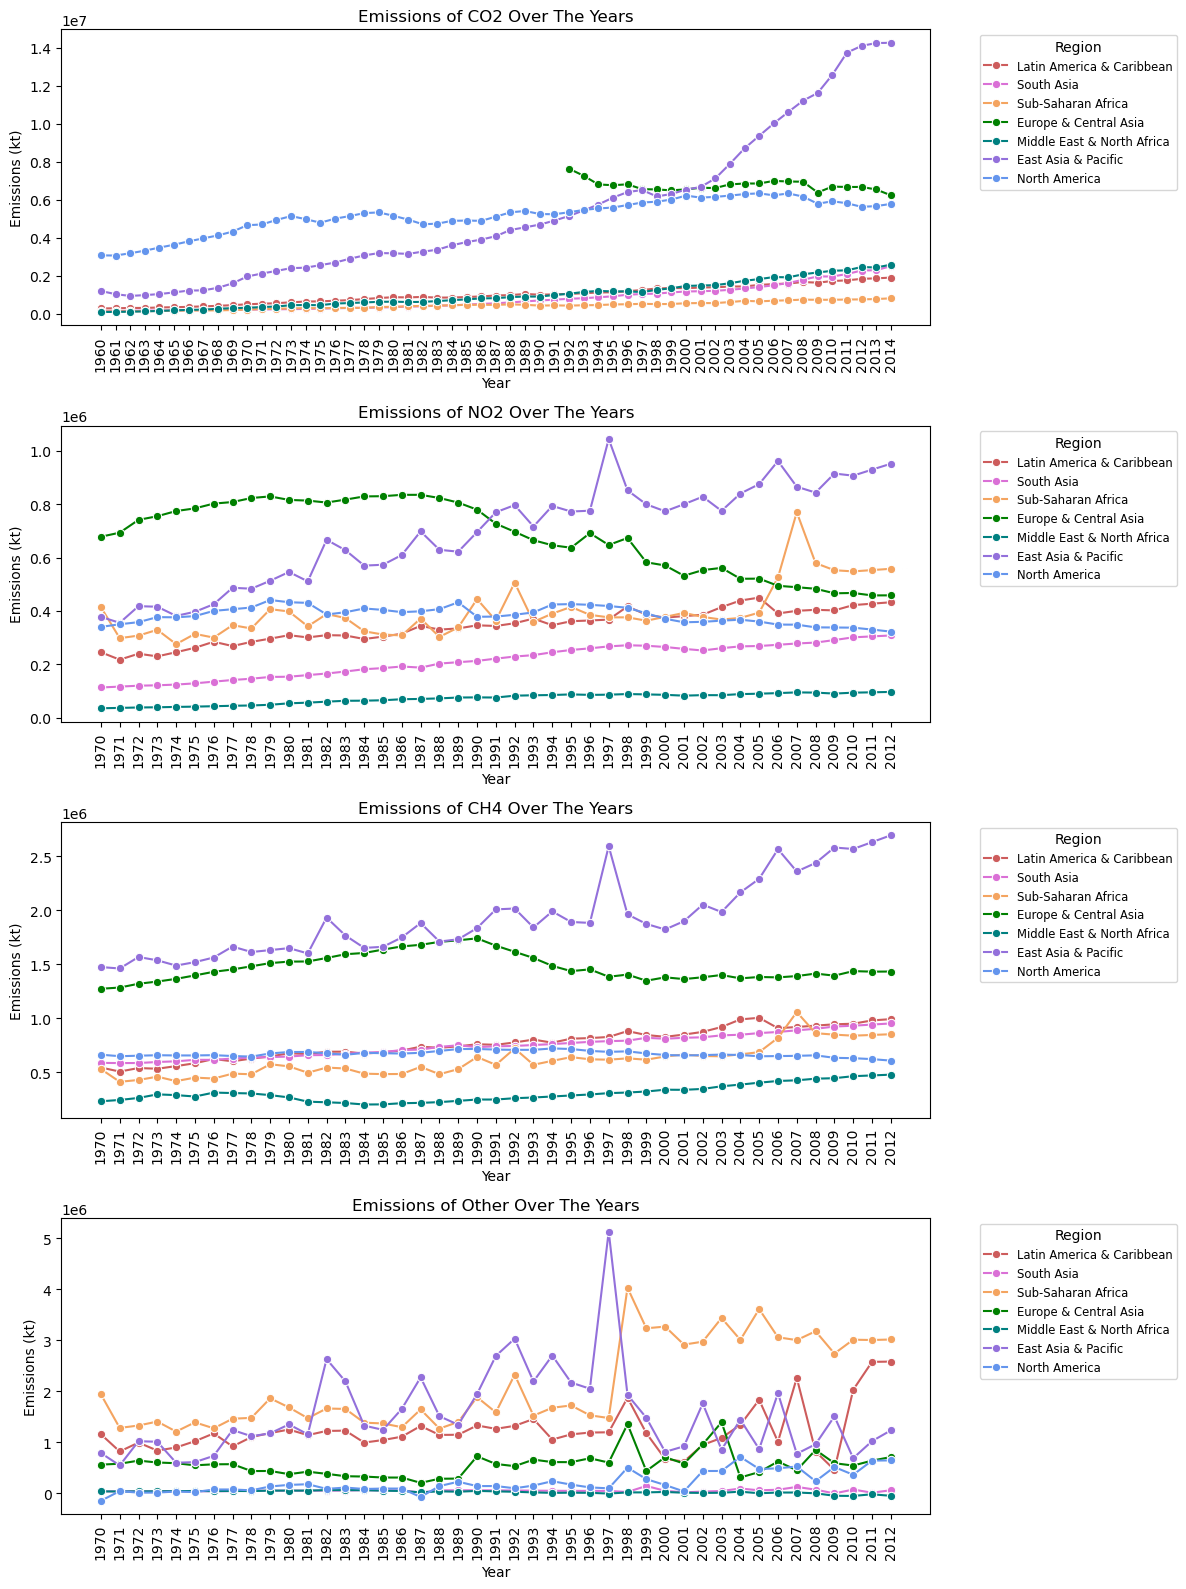

In [82]:
#Assigning colours to ensure consistency across plots
region_colors = {
    'North America': 'cornflowerblue',
    'South Asia': 'orchid',
    'Europe & Central Asia': 'green',
    'Latin America & Caribbean': 'indianred',
    'East Asia & Pacific': 'mediumpurple',
    'Middle East & North Africa': 'teal',
    'Sub-Saharan Africa': 'sandybrown'}

num_pollutants = len(pollutants)
fig, axes = plt.subplots(nrows=num_pollutants, ncols=1, figsize=(12, 4 * num_pollutants))

# Creating separate plots for each pollutant, (each with all regions)
for i, pollutant in enumerate(pollutants):
    ax = axes[i]
    for region in main_regions:
        region_data = Emissions_R_df_pollutants[(Emissions_R_df_pollutants['Indicator Name'] == pollutant) & (Emissions_R_df_pollutants['Country Name'] == region)]
        sns.lineplot(data=region_data, x='Year', y='Indicator Value', label=region, 
                     color=region_colors[region], marker='o', ax=ax)
    
    ax.set_title(f'Emissions of {pollutant} Over The Years')
    ax.set_xlabel('Year')
    ax.set_ylabel('Emissions (kt)')
    ax.legend(title='Region', bbox_to_anchor=(1.05, 1), fontsize = 'small')
    ax.tick_params(axis='x', rotation=90) #Changing the orientation of the 'Year' labels so that they are clearer to read

plt.tight_layout()
plt.show()

**Conclusions Drawn**  

Above I have created a plot for each pollutant and plotted the sum of emissions for each year, per region. For the first three pollutants, it can easily be observed that the East Asia & Pacific region have been increasing their emissions over the years. Another trend that can easily be observed, especially for CH4 and NO2 pollutants, is Europe & Central Asia have had high emissions for years. However, it can be noticed that they have been making considerable efforts to decrease emissions since the 1990s. 

For South Asia and the Middle East & North Africa regions, the emissions for each of the pollutants have been consistent over the years. Their emissions are very low for all pollutants. 

For North America and Latin America & Caribbean regions, the emissions for each pollutant have been slowly trending upwards. 

Finally, the Sub-Saharan Africa region appears to have increased emissions of their pollutants in most recent years.

-------

<p>It seems that countries in East Asia and the Pacific are the worst dealing with pollutant emissions. We also see that Europe and Central Asia have been making some efforts to reduce their emissions. Surprisingly this is not the case with North America and Sub-Saharan Africa, which levels have been increasing over the years as well. </p>

<h3>Exercise 8  (10 marks):</h3>
<p>In Exercise 7 we discovered some interesting features of the distribution of the emissions over the years. Let us explore these features in more detail. </p>

<h4>8.1 (5 marks)</h4>
<p>Which are the top five countries that have been in the top 10 of <code>CO2</code> emitters over the years? Have any of these countries made efforts to reduce the amount of CO2 emissions over the last 10 years?</p>

**Answer.**

In [89]:
Emissions_C_df_CO2 = Emissions_C_df_pollutants[Emissions_C_df_pollutants['Indicator Name'] == 'CO2']

#Finds the top 10 countries for each year
top_10_year = Emissions_C_df_CO2.groupby('Year').apply(lambda x: x.sort_values('Indicator Value', ascending = False).head(10)).reset_index(drop=True)

#Counts the number of times the countries have been in the top 10 
top_5countries = top_10_year['Country Name'].value_counts()

#Top 5 countries, over the years
top_5countries.head()

Country Name
United States    55
Japan            55
India            55
China            55
Canada           54
Name: count, dtype: int64

In [90]:
#Puts the top 5 countries into a list > to reference later
top_5countries = top_5countries.head().index.tolist()

#Checking the latest year in the data to find range for 'last 10 years'
Emissions_C_df_CO2['Year'].max()

#Last 10 years, 2004 - 2014

'2014'

In [91]:
#creating df with only top 5 countries for the last 10 years
recent_years = Emissions_C_df_CO2[(Emissions_C_df_CO2['Country Name'].isin(top_5countries)) &
                             (Emissions_C_df_CO2['Year'] >= '2004')]
recent_years = recent_years.sort_values(by=['Country Name', 'Year'])
recent_years.head(13)

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
491323,Canada,CAN,CO2,EN.ATM.CO2E.KT,2004,552198.862
502411,Canada,CAN,CO2,EN.ATM.CO2E.KT,2005,557417.003
513499,Canada,CAN,CO2,EN.ATM.CO2E.KT,2006,543819.767
524587,Canada,CAN,CO2,EN.ATM.CO2E.KT,2007,554355.058
535675,Canada,CAN,CO2,EN.ATM.CO2E.KT,2008,561028.998
546763,Canada,CAN,CO2,EN.ATM.CO2E.KT,2009,536764.459
557851,Canada,CAN,CO2,EN.ATM.CO2E.KT,2010,534670.602
568939,Canada,CAN,CO2,EN.ATM.CO2E.KT,2011,537112.824
580027,Canada,CAN,CO2,EN.ATM.CO2E.KT,2012,517457.704
591115,Canada,CAN,CO2,EN.ATM.CO2E.KT,2013,517160.677


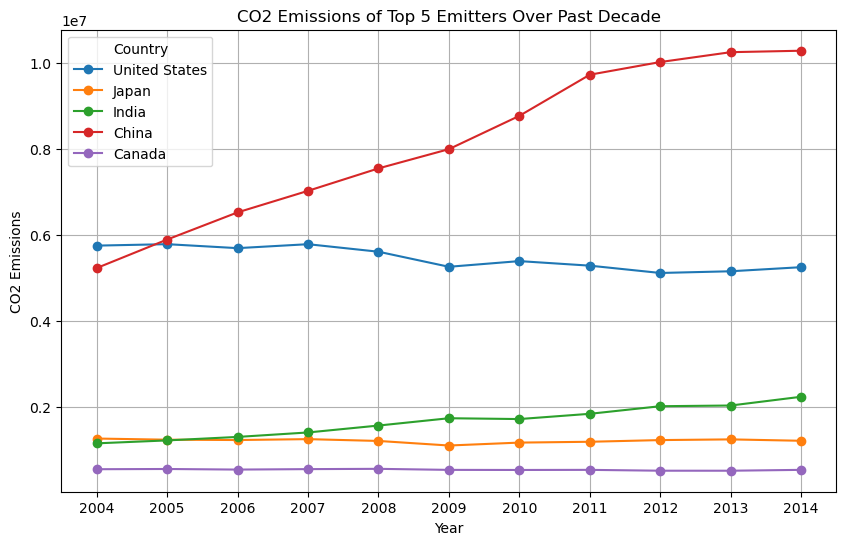

In [92]:
plt.figure(figsize=(10, 6))

for country in top_5countries:
    country_stat = recent_years[recent_years['Country Name'] == country]
    plt.plot(country_stat['Year'], country_stat['Indicator Value'], marker='o', label=country)

plt.grid(True)
plt.title("CO2 Emissions of Top 5 Emitters Over Past Decade")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")
plt.legend(title="Country")
plt.show()

**Observations**

Above, I have plotted the yearly CO2 emissions from the top 5 countries. The following observations can be made:
- China and India have made no effort and continue increasing their emissions yearly.
- The United States and Japan have made very little effort to decrease their emissions.
- Canada's emission levels have stayed constant.

Overall, the top 5 countries are not attempting to reduce their emissions in the last 10 years.

-------

<h4>8.2  (5 marks)</h4>
<p>Are these five countries carrying out the burden of most of the emissions emitted over the years globally? Can we say that the rest of the world is making some effort to control their polluted gasses emissions over the years?</p>

**Answer.**

In [97]:
#Calculate yearly global CO2 emissions
yearly_CO2 = Emissions_C_df_CO2.groupby('Year')['Indicator Value'].sum()

#Calculate yearly global CO2 emissions from top 5 countries
top5_emissions = Emissions_C_df_CO2[(Emissions_C_df_CO2['Country Name'].isin(top_5countries))]
yearly_CO2_top = top5_emissions.groupby('Year')['Indicator Value'].sum()

#Find the percentage that the top 5 countries contribute to yearly global CO2 emissions
contributions = (yearly_CO2_top / yearly_CO2)
contributions

Year
1960    0.636775
1961    0.617920
1962    0.605659
1963    0.600791
1964    0.597295
1965    0.597550
1966    0.600786
1967    0.598099
1968    0.594870
1969    0.595633
1970    0.602416
1971    0.598674
1972    0.600524
1973    0.594018
1974    0.588826
1975    0.588613
1976    0.582172
1977    0.586204
1978    0.584399
1979    0.576215
1980    0.570335
1981    0.570433
1982    0.565601
1983    0.569785
1984    0.576828
1985    0.573613
1986    0.572281
1987    0.577059
1988    0.585617
1989    0.582639
1990    0.589620
1991    0.554689
1992    0.464981
1993    0.475319
1994    0.490444
1995    0.497629
1996    0.500473
1997    0.506522
1998    0.502147
1999    0.503012
2000    0.503600
2001    0.498456
2002    0.505459
2003    0.512899
2004    0.521710
2005    0.531387
2006    0.533565
2007    0.543351
2008    0.543421
2009    0.553285
2010    0.556464
2011    0.565585
2012    0.564561
2013    0.572006
2014    0.577157
Name: Indicator Value, dtype: float64

**Observations**

From the data above, we can say that the top five countries account for most of the CO2 emissions each year. In almost every year, the top five countries account for more than 50% of the CO2 emissions. 

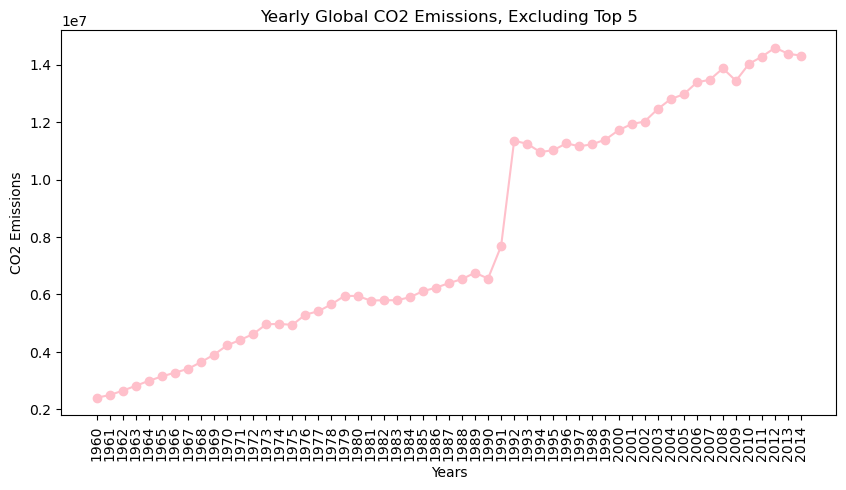

In [99]:
#Look at trends the rest of the world 

not_top5 = Emissions_C_df_CO2[~Emissions_C_df_CO2['Country Name'].isin(top_5countries)]
year_not_top5 = not_top5.groupby('Year')['Indicator Value'].sum()


plt.figure(figsize=(10, 5))
plt.plot(year_not_top5.index, year_not_top5, label='Rest of the World', marker='o', linestyle='-', color='pink')

plt.title("Yearly Global CO2 Emissions, Excluding Top 5")
plt.xlabel("Years")
plt.ylabel("CO2 Emissions")
plt.xticks(rotation=90)

plt.show()

**Observations**

From the graph, it does not appear that the rest of the world is reducing their CO2 emissions either. The amount of emissions each year continues to increase.

-------

<h2>The health impacts of air pollution</h2>

<h3>Exercise 9  (10 marks):</h3>
<p>One of the main contributions of poor health from air pollution is particulate matter. In particular, very small particles (those with a size less than 2.5 micrometres ($\mu$m)) can enter and affect the respiratory system. The <code>PM2.5</code> indicator measures the average level of exposure of a nation's population to concentrations of these small particles. The <code>PM2.5_WHO</code> measures the  percentage of the population who are exposed to ambient concentrations of these particles that exceed some thresholds set by the World Health Organization (WHO). In particular, countries with a higher <code>PM2.5_WHO</code> indicator are more likely to suffer from bad health conditions. </p>
<h4>9.1  (7 marks)</h4>
<p>The client would like to know if there is any relationship between the <code>PM2.5_WHO</code> indicator and the level of income of the general population, as well as how this changes over time. What plot(s) might be helpful to solve the client's question?  What conclusion can you draw from your plot(s) to answer their question?</p>
<p><strong>Hint:</strong> The DataFrame <code>WDI_countries</code> contains a column named <code>Income Group</code>. </p>

**Answer.**

To solve the client's question, I plan on using a line plot to determine the relation between the indicator and the level of income of the general population. I plan to use a line plot diagram as this is the best diagram to display changes over time. On the x-axis, years will be listed while on the y-axis, the PM2.5_WHO indicator values will be displayed. Each income group will have their own line on the plot. 
The indicator values plotted for each year will be an average of all the values for that particular year and income group.

In [106]:
#First merge the country Emissions data frame with the Country data frame with income groups
income_groups_data = pd.merge(Emissions_C_df, WDI_country,
                             on = "Country Code",
                             how = 'inner')
income_groups_data['Income Group'].unique()

array(['Low income', 'Upper middle income', 'Lower middle income',
       'High income'], dtype=object)

In [107]:
#Filter to only Indicator name PM2.5_WHO
income_groups_data_pm = income_groups_data[income_groups_data['Indicator Name'] == 'PM2.5_WHO']
income_groups_data_pm.head()
income_order = ['Low income', 'Lower middle income', 'Upper middle income','High income']

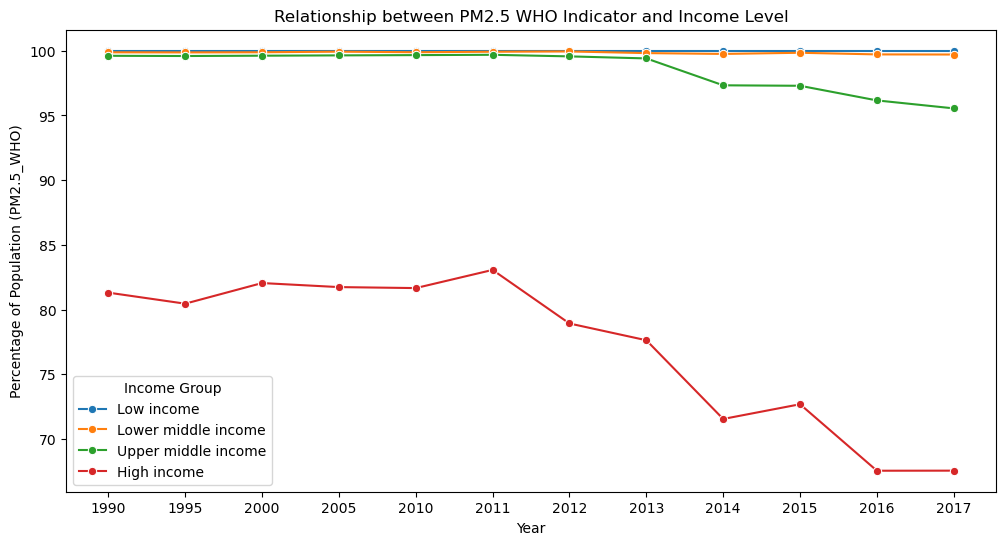

In [108]:
#Creating plots for each Income group
income_info = income_groups_data_pm.groupby(['Year', 'Income Group'])['Indicator Value'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=income_info, x='Year', y='Indicator Value', hue='Income Group', marker='o', hue_order = income_order)
plt.title('Relationship between PM2.5 WHO Indicator and Income Level')
plt.xlabel('Year')
plt.ylabel('Percentage of Population (PM2.5_WHO)')
plt.show()

From this plot, we can suggest that there is a correlation/relationship between the PM2.5_WHO indicator and the level of income in the population. We can observe that lower-income population groups are more exposed to dangerous concentrations of these particles. The populations in the first two income groups, low-income and lower-middle-income, are almost entirely exposed to the harmful particle (practically 100%). For the upper middle income, there has been a slight improvement since 2013 as the percentage of the population exposed is decreasing, but still above 90%. Finally, the high-income population group has the lowest percentage of the population exposed to dangerous levels of the particles. Overall we can see that the percentage of the population exposed to the harmful particles is in the order of lowest income group to highest income group. However, we can not definitively say that these variables cause the other, many other confounding factors can contribute to this.

-------

<h4>9.2  (3 marks)</h4>
<p>What do you think are the causes behind the results in Exercise 9.1?</p>

**Answer.**

As briefly mentioned in the last question, confounding variables can contribute to the relationship witnessed between income groups and the PM2.5_WHO indicator values. For instance, more high-income groups may reside in developed countries. Developed countries have the resources and the ability to filter the air of these harmful particles. By filtering the air of these particles, the air will be cleaner and less of the population will be exposed to these high concentrations of PM2.5 particles. In contrast, low-income groups may live in less-developed countries that do not have methods of cleaning the air; thus, they will exposed to high levels of particle matter. 

-------

<h3>Exercise 10  (30 marks):</h3>
<p>Finally, our client is interested in investigating the impacts and relationships between <strong>high levels of exposure to particle matter</strong> and <strong>the health of the population</strong>. Coming up with additional data for this task may be infeasible for the client, thus they have asked us to search for relevant health data in the <code>WDIdata.csv</code> file and work with that. </p>

<h4>10.1  (4 marks)</h4>
<p>Which indicators present in the file  <code>WDISeries.csv</code> file might be useful to solve the client's question? Explain.</p>
<p><strong>Note:</strong> Naming one or two indicators is more than enough for this question. </p>

**Answer.**

In [118]:
WDI_series = pd.read_csv("WDI_csv/WDISeries.csv")
(WDI_series['Indicator Name'].unique())

array(['Agricultural machinery, tractors',
       'Fertilizer consumption (% of fertilizer production)',
       'Fertilizer consumption (kilograms per hectare of arable land)',
       ..., 'Intentional homicides, male (per 100,000 male)',
       'Intentional homicides (per 100,000 people)',
       'Presence of peace keepers (number of troops, police, and military observers in mandate)'],
      dtype=object)

After reviewing the list of unique indicators in the WDI_series file, I noticed the following indicators:

-  'Mortality rate attributed to household and ambient air pollution, age-standardized, female (per 100,000 female population)'
-  'Mortality rate attributed to household and ambient air pollution, age-standardized, male (per 100,000 male population)'
-  'Mortality rate attributed to household and ambient air pollution, age-standardized (per 100,000 population)'
-  'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)'
-  'PM2.5 pollution, population exposed to levels exceeding WHO Interim Target-1 value (% of total)'
-  'PM2.5 pollution, population exposed to levels exceeding WHO Interim Target-2 value (% of total)'
-  'PM2.5 pollution, population exposed to levels exceeding WHO Interim Target-3 value (% of total)'
-  'PM2.5 air pollution, population exposed to levels exceeding WHO guideline value (% of total)'


I will only be using the 'Mortality rate attributed to household and ambient air pollution, age-standardized (per 100,000 population)' and 'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)' indicators. These indicators are directly related to the clients question. The indicator for mortality rate directly looks at the mortality rate from pollution. While the PM2.5 indicator directly looks at the average exposure, rather than the percent of population.

In [120]:
#Looking for series code for easy filtering
WDI_series_f =WDI_series[WDI_series['Indicator Name'].str.contains('Mortality rate attributed to household and ambient air pollution, age-standardized') | 
WDI_series['Indicator Name'].str.contains('PM2.5')]
WDI_series_f


,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
247,EN.ATM.PM25.MC.M3,Environment: Emissions,"PM2.5 air pollution, mean annual exposure (mic...",NaN,Population-weighted exposure to ambient PM2.5 ...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Brauer, M. et al. 2017, for the Global Burden ...","A. van Donkelaar, R.V. Martin, M. Brauer, N.C....",Air pollution places a major burden on world h...,NaN,NaN,NaN,CC BY-4.0,NaN
248,EN.ATM.PM25.MC.T1.ZS,Environment: Emissions,"PM2.5 pollution, population exposed to levels ...",NaN,Percent of population exposed to ambient conce...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Brauer, M. et al. 2017, for the Global Burden ...","A. van Donkelaar, R.V. Martin, M. Brauer, N.C....",Air pollution places a major burden on world h...,NaN,NaN,NaN,CC BY-4.0,NaN
249,EN.ATM.PM25.MC.T2.ZS,Environment: Emissions,"PM2.5 pollution, population exposed to levels ...",NaN,Percent of population exposed to ambient conce...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Brauer, M. et al. 2017, for the Global Burden ...","A. van Donkelaar, R.V. Martin, M. Brauer, N.C....",Air pollution places a major burden on world h...,NaN,NaN,NaN,CC BY-4.0,NaN
250,EN.ATM.PM25.MC.T3.ZS,Environment: Emissions,"PM2.5 pollution, population exposed to levels ...",NaN,Percent of population exposed to ambient conce...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Brauer, M. et al. 2017, for the Global Burden ...","A. van Donkelaar, R.V. Martin, M. Brauer, N.C....",Air pollution places a major burden on world h...,NaN,NaN,NaN,CC BY-4.0,NaN
251,EN.ATM.PM25.MC.ZS,Environment: Emissions,"PM2.5 air pollution, population exposed to lev...",NaN,Percent of population exposed to ambient conce...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Brauer, M. et al. 2017, for the Global Burden ...","A. van Donkelaar, R.V. Martin, M. Brauer, N.C....",Air pollution places a major burden on world h...,NaN,NaN,NaN,CC BY-4.0,NaN
984,SH.STA.AIRP.FE.P5,Health: Mortality,Mortality rate attributed to household and amb...,NaN,Mortality rate attributed to household and amb...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"World Health Organization, Global Health Obser...",NaN,Air pollution is one of the biggest environmen...,NaN,NaN,NaN,CC BY-4.0,NaN
985,SH.STA.AIRP.MA.P5,Health: Mortality,Mortality rate attributed to household and amb...,NaN,Mortality rate attributed to household and amb...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"World Health Organization, Global Health Obser...",NaN,Air pollution is one of the biggest environmen...,NaN,NaN,NaN,CC BY-4.0,NaN
986,SH.STA.AIRP.P5,Health: Mortality,Mortality rate attributed to household and amb...,NaN,Mortality rate attributed to household and amb...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"World Health Organization, Global Health Obser...",NaN,Air pollution is one of the biggest environmen...,NaN,NaN,NaN,CC BY-4.0,NaN


-------

<h4>10.2  (4 marks)</h4>
<p>Use the indicators provided in Exercise 10.1 to give valuable information to the client. </p>

**Answer.**

**Cleaning DFs**

In [125]:
mortality = WDI_data[(WDI_data['Indicator Code'] == 'SH.STA.AIRP.P5')]

In [126]:
mortality = pd.melt(
    mortality, 
    id_vars=['Country Name','Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Mortality Average'
)

In [127]:
#Dropping all of the Unnamed 64 rows
mortality = mortality[mortality['Year'] != 'Unnamed: 64']
mortality.shape

(15840, 6)

In [128]:
#Observing the number of null values
print(mortality.isnull().sum())

Country Name             0
Country Code             0
Indicator Name           0
Indicator Code           0
Year                     0
Mortality Average    15611
dtype: int64


In [129]:
#Even though there are many NaN values for mortality rate, there is no way to accurately fill in the information, will drop these rows
mortality = mortality.dropna(subset=['Mortality Average'])

In [130]:
#Repeating process for PM2.5 indicator 
pollution = WDI_data[(WDI_data['Indicator Code'] == 'EN.ATM.PM25.MC.M3')]

In [131]:
pollution = pd.melt(
    pollution, 
    id_vars=['Country Name','Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Average Exposure'
)

In [132]:
#Dropping all of the Unnamed 64 rows and NaN row values
pollution = pollution[pollution['Year'] != 'Unnamed: 64']
pollution = pollution.dropna(subset=['Average Exposure'])

In [133]:
#I will consider anything above WHO Interim Target-2 value as 'HIGH EXPOSURE'
#The definition in the WDI Series csv mentions that this implies exposure above 25 micrograms per cubic meter
high_exposure = pollution[pollution['Average Exposure'] >= 25]

**Analysis**

In [135]:
high_exposure_mortality = pd.merge(high_exposure, mortality, on=['Country Name','Year','Country Code'], how="inner")
high_exposure_mortality

,Country Name,Country Code,Indicator Name_x,Indicator Code_x,Year,Average Exposure,Indicator Name_y,Indicator Code_y,Mortality Average
0,Arab World,ARB,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,2016,58.764905,Mortality rate attributed to household and amb...,SH.STA.AIRP.P5,101.932592
1,Early-demographic dividend,EAR,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,2016,59.870180,Mortality rate attributed to household and amb...,SH.STA.AIRP.P5,142.558914
2,East Asia & Pacific,EAS,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,2016,39.520542,Mortality rate attributed to household and amb...,SH.STA.AIRP.P5,105.033765
3,East Asia & Pacific (excluding high income),EAP,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,2016,42.299507,Mortality rate attributed to household and amb...,SH.STA.AIRP.P5,114.502209
4,East Asia & Pacific (IDA & IBRD countries),TEA,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,2016,42.431890,Mortality rate attributed to household and amb...,SH.STA.AIRP.P5,113.345231
...,...,...,...,...,...,...,...,...,...
103,United Arab Emirates,ARE,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,2016,40.522103,Mortality rate attributed to household and amb...,SH.STA.AIRP.P5,54.700000
104,Uzbekistan,UZB,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,2016,27.814347,Mortality rate attributed to household and amb...,SH.STA.AIRP.P5,81.100000
105,Vietnam,VNM,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,2016,30.241312,Mortality rate attributed to household and amb...,SH.STA.AIRP.P5,64.500000
106,"Yemen, Rep.",YEM,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,2016,50.127626,Mortality rate attributed to household and amb...,SH.STA.AIRP.P5,194.200000


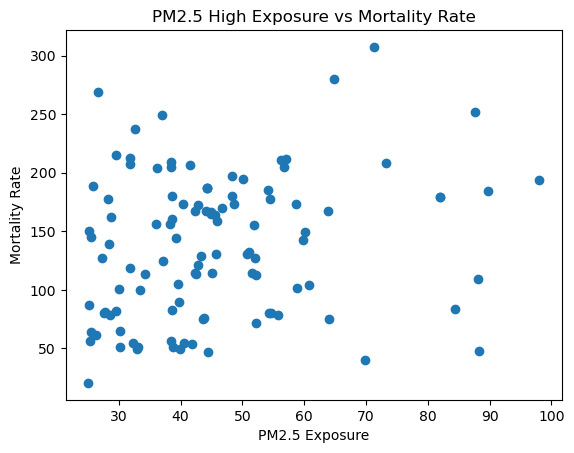

In [136]:
plt.scatter(high_exposure_mortality['Average Exposure'], high_exposure_mortality['Mortality Average'])
plt.xlabel('PM2.5 Exposure')
plt.ylabel('Mortality Rate')
plt.title('PM2.5 High Exposure vs Mortality Rate')
plt.show()

In [137]:
corr = np.corrcoef(high_exposure_mortality['Average Exposure'],high_exposure_mortality['Mortality Average'])[0,1]
print(f'The correlation between High Exposure and Mortality Rate is {corr}')

The correlation between High Exposure and Mortality Rate is 0.21075077480727777


**Observations**

We have graphed a scatterplot and correlation between High Exposure and Mortality Rate above. The correlation being 0.2108. This correlation is not very high. Furthermore, the scatterplot does not have a clear relationship. 

However, we would typically expect a relationship, this would suggest there are other factors that are impacting the relationship. Furthermore, it is also important to note that the mortality data was only for 2016. So, in order to truly declare that there is a relationship, we should observe this for several years.

-------

<h4>10.3  (4 marks)</h4>
<p>Extend the analysis above to find some countries of interest. These are defined as</p>
<ul>
<li>The countries that have a high mortality rate due to household and ambient air pollution, but with low PM2.5 exposure</li>
<li>The countries that have a low mortality rate due to household and ambient air pollution, but with high PM2.5 exposure</li>
</ul>

**Answer.**

**EXPOSURE THRESHOLD**

Based on values WHO Interim Target-2 and Target 3 levels.

HIGH EXPOSURE - equal to/more than 25 micrograms per cubic meter

LOW EXPOSURE - less than 15 micrograms per cubic meter

**MORTALITY THRESHOLD**

I will determine these thresholds by checking quantiles of the data.

LOW MORTALITY - lower than 25 percentile (quantile 1)

HIGH MORTALITY - higher than 75 percentile (quantile 3)

In [143]:
#Filtering pollution df based on countries
pollution_C = pollution[pollution['Country Code'].isin(countries['Country Code'])]
exposure_mortality = pd.merge(pollution_C, mortality, on=['Country Name','Year','Country Code'], how="inner")

In [144]:
mortality_quantiles = exposure_mortality['Mortality Average'].quantile([0.25, 0.75])
mortality_quantiles

#I will take 34 to be the low mortality threshold and 147 to be the high mortality threshold

0.25     33.75
0.75    147.00
Name: Mortality Average, dtype: float64

In [145]:
#high mortality rate, low PM2.5 exposure
highm_lowp = exposure_mortality[
    (exposure_mortality['Mortality Average'] > 147) &
    (exposure_mortality['Average Exposure'] < 15)]
highm_lowp_countries = highm_lowp['Country Name'].tolist()

In [146]:
#low mortality rate, high PM2.5 exposure
lowm_highp = exposure_mortality[
    (exposure_mortality['Mortality Average'] < 34) &
    (exposure_mortality['Average Exposure'] >= 25)]
lowm_highp_countries = lowm_highp['Country Name'].tolist()

In [147]:
print(f'Based on my thresholds, countries of interest that have high mortality rates but low PM2.5 exposure are:') 
print(f'{highm_lowp_countries} \n')
print(f'Countries of interest that have low mortality rates but high PM2.5 exposure are:')
print(f'{lowm_highp_countries}')


Based on my thresholds, countries of interest that have high mortality rates but low PM2.5 exposure are:
['Micronesia, Fed. Sts.', 'Papua New Guinea'] 

Countries of interest that have low mortality rates but high PM2.5 exposure are:
['Korea, Rep.']


-------

<h4>10.4  (10 marks)</h4>
<p>Finally, we want to look at the mortality data by income. We expect higher income countries to have lower pollution-related mortality. Find out if this assumption holds. Calculate summary statistics and histograms for each income category and note any trends.</p>

**Answer.**

In [151]:
#First merge the Mortality data frame with the Country data frame with income groups
income_mortality_data = mortality.merge(WDI_country[["Country Code", 'Income Group']],
                                        on = "Country Code",how = 'left')

#Obtaining Summary statistics
income_mortality_stats = income_mortality_data.groupby('Income Group')['Mortality Average'].describe()
income_mortality_stats = income_mortality_stats.reindex(income_order)
income_mortality_stats

,count,mean,std,min,25%,50%,75%,max
Income Group,,,,,,,,
Low income,31.0,188.341935,52.959341,75.2,157.65,193.8,212.350,324.1
Lower middle income,46.0,136.441304,55.566699,41.9,101.85,138.4,167.725,307.4
Upper middle income,54.0,63.937037,29.618125,23.3,46.80,61.1,77.950,177.7
High income,52.0,25.142308,19.123534,7.0,11.90,20.0,33.625,103.8


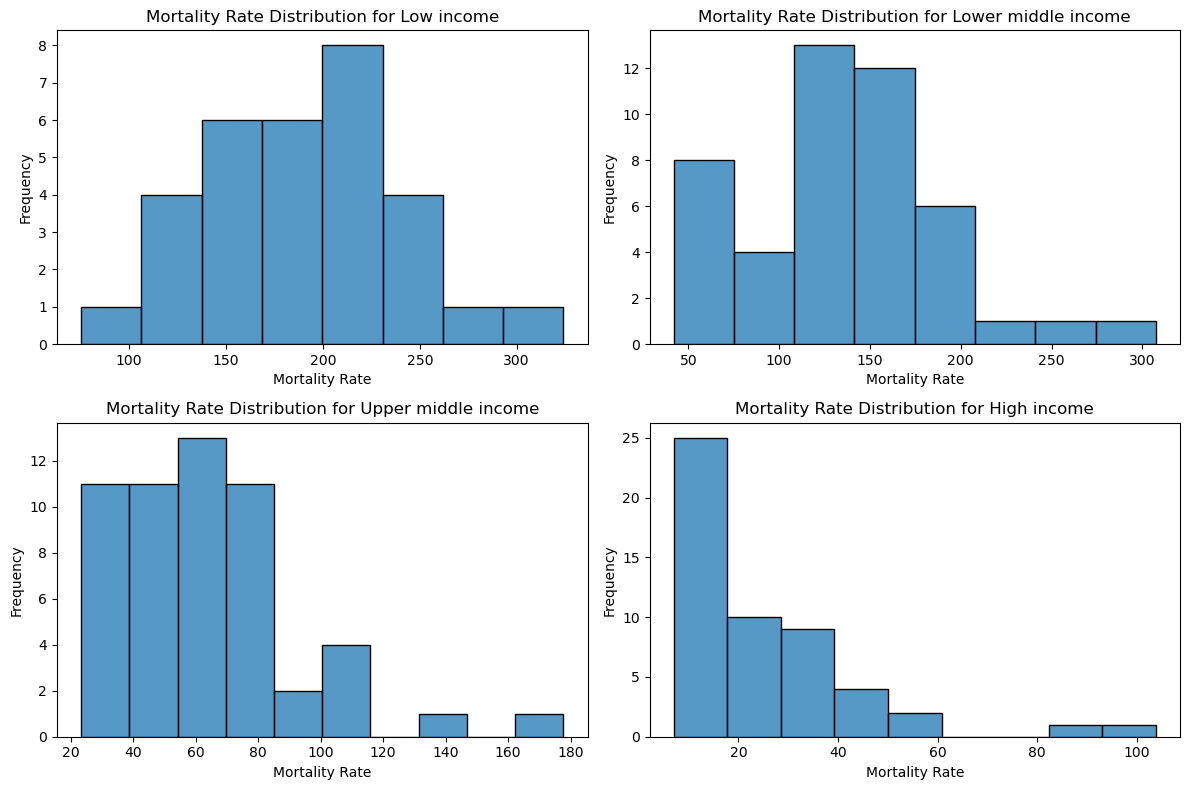

In [152]:
plt.figure(figsize=(12, 8))
for i, group in enumerate(income_order, 1):
    plt.subplot(2, 2, i)
    sns.histplot(income_mortality_data[income_mortality_data['Income Group'] == group]['Mortality Average'])
    plt.title(f'Mortality Rate Distribution for {group}')
    plt.xlabel('Mortality Rate')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations**

Above I have found the summary statistics for each income group, as well as plotted a histogram. From the histograms, we can observe that the mortality rate is lower for 'higher' income groups. That is, the mortality rate is higher for low income and lower middle income groups compared to upper middle and high income groups. 
This can only be easily read from the summary statistics as the mean for the lower income groups is above 100 people, almost 200 for the low income group. In contrast, the higher income groups have a mortality rate of less than 100 people per 100,000 people. 

Overall, we can claim there is a relationship between income groups and mortality rate from ambient pollution.

-------

<h4>10.5  (8 marks)</h4>
<p>At the start, we asked some questions. Based on your analysis, provide a short answer to each of these:</p>
<ol>
<li>Are we making any progress in reducing the amount of emitted pollutants across the globe?</li>
<li>Which are the critical regions where we should start environmental campaigns?</li>
<li>Are we making any progress in the prevention of deaths related to air pollution?</li>
<li>Which demographic characteristics seem to correlate with the number of health-related issues derived from air pollution? </li>
</ol>

**Answer.**

**Question 1**
- No, we have not been making progress to reduce the amounts of pollutants across the globe.
- The emissions for all pollutants, CO2, NO2, CH4, and other, continue to rise each year.
- When we specifically observed CO2, we found that the majority of emissions were from the top 5 countries: China, Japan, India, the United States and Canada. Therefore, if we truly want to lower yearly global emissions, we should target these countries to reduce emissions levels. However, even though these top 5 countries have the highest emissions, the rest of the world should also make an effort to reduce their CO2 emissions as they rise yearly as well. 

**Question 2**
- We should primarily focus on the East Asia & Pacific and Sub-Saharan Africa regions.
- The East Asia and Pacific region has been steadily increasing their emissions levels for all pollutants over the years. It does not seem like they are attempting to reduce their emissions in any way. Therefore, an environmental campaign in this region may help reduce the emissions in this region.
- The Sub-Saharan Africa region has increased many of their emission levels for all pollutants in recent years. This may imply they have developed new systems in their area; however, they must also acknowledge their impact on their environment. If this is true, an environmental campaign will guide their new systems to reduce their emissions. Otherwise, the environmental campaign may help them reduce the emissions in the region as a whole. 


**Question 3**
- We do not have enough data to conclude this. In the data, we were only provided one year (2016) of data for mortality rates. Therefore, we are unable to see whether there has been any progress in the prevention of deaths related to air pollution. 

**Question 4**
- From the data that we analyzed, income is a big factor that correlates with the number of health-related issues derived from air pollution. Lower-income groups tend to have a higher mortality rate from ambient pollution and face higher levels of exposure to harmful particle matter. In contrast, high-income groups have a lower mortality rate from ambient pollution and face lower levels of exposure to harmful particle matter.
- We cannot say this relation is causal, but there seems to be some correlation between these variables.

-------